In [1]:
import numpy as np
from scipy import integrate
from scipy.optimize import minimize
from scipy.stats import chi2 as chi2_dist
import matplotlib.pyplot as plt

from astropy import units as u
from astropy import constants as const
from astropy.cosmology import FlatLambdaCDM



# ── Fiducial cosmology ────────────────────────────────────────────────────────
H0_fid = 70.0 * u.km / u.s / u.Mpc
Omega_b_fid = 0.049
Omega_m_fid = 0.3
cosmo_fid = FlatLambdaCDM(H0=H0_fid, Om0=Omega_m_fid, Ob0=Omega_b_fid)

f_IGM = 0.83   # fraction of baryons in the IGM (fixed)

# ── Data ─────────────────────────────────────────────────────────────────────
data = np.loadtxt('data/frb_sample_000100.txt')
z_obs = data[:, 0]   # observed redshifts
DM_obs = data[:, 1]  # observed DMs [pc/cm³]
N_frb = len(z_obs)
print(f'Loaded {N_frb} FRBs,  z ∈ [{z_obs.min():.3f}, {z_obs.max():.3f}]')


# ── Signal model ──────────────────────────────────────────────────────────────
def DM_cosmic(z, H0, Omega_b, Omega_m, n_points=1024):
    """Mean cosmic DM [pc/cm³] via numerical integration of the line-of-sight integral."""
    cosmo = FlatLambdaCDM(H0=H0, Om0=Omega_m, Ob0=Omega_b)
    prefactor = (3 * const.c * f_IGM * Omega_b * H0) / (8 * np.pi * const.G * const.m_p)
    prefactor = prefactor.to(u.pc / u.cm**3)

    is_scalar = np.isscalar(z)
    z_arr = np.atleast_1d(z)
    z_prime = np.linspace(0, np.max(z_arr), n_points)
    integrand = (1 + z_prime) / cosmo.efunc(z_prime)
    cumul = np.concatenate(([0.0], integrate.cumulative_simpson(integrand, x=z_prime)))

    result = prefactor * np.interp(z_arr, z_prime, cumul)
    return result[0] if is_scalar else result


# ── Per-FRB variance model ────────────────────────────────────────────────────
SIGMA_HOST = 100.0  # host-galaxy DM uncertainty [pc/cm³]


def sigma_host_sq(z):
    """Host-galaxy DM variance: σ_host²/(1+z)²  [pc/cm³]²"""
    return SIGMA_HOST**2 / (1.0 + z)**2


def sigma_cosmic_sq(z):
    """Cosmic line-of-sight DM variance (polynomial fit)  [pc/cm³]²"""
    return 2.43502820e+03*z**3 - 1.71613980e+04*z**2 + 4.76903727e+04*z - 1.94145871e+01


def sigma_sq(z):
    """Total per-FRB DM variance = host + cosmic  [pc/cm³]²"""
    return sigma_host_sq(z) + sigma_cosmic_sq(z)

Loaded 100 FRBs,  z ∈ [0.102, 1.557]


# 4.1 MLE for Fast Radio Burst Cosmology

Fast radio bursts (FRBs) are millisecond radio transients whose dispersion measure (DM) accumulates along the line of sight. For a localised FRB at redshift $z$, the average cosmic contribution is

$$\overline{\mathrm{DM}}_{\mathrm{cosmic}}(z;\boldsymbol{\theta}) = \frac{3cH_0\Omega_{\mathrm{b}} f_{\mathrm{IGM}}}{8\pi G m_p} \int_0^z \frac{1+z'}{E(z';\Omega_{\mathrm{m}})}\,\mathrm{d}z',$$

where $E(z) = \sqrt{\Omega_{\mathrm{m}}(1+z)^3 + (1-\Omega_{\mathrm{m}})}$ for a flat $\Lambda\mathrm{CDM}$ universe, $f_{\mathrm{IGM}} = 0.83$ is fixed, and the free parameters are $\boldsymbol{\theta} = (H_0, \Omega_{\mathrm{b}}, \Omega_{\mathrm{m}})$. We fit these parameters to a real catalogue of $N = 100$ localised FRBs and work through the MLE workflow of Fig. 19 step by step.

**Pre-implemented for you:**
 - `DM_cosmic(z, H0, Omega_b, Omega_m)` — evaluates $\overline{\mathrm{DM}}_{\mathrm{cosmic}}$ via numerical integration
 - `sigma_host_sq(z)`, `sigma_cosmic_sq(z)`, `sigma_sq(z)` — the per-FRB variance and its two components
 - Data loading cell (reads `data/frb_sample_000100.txt` into arrays `z_obs`, `DM_obs`)

---

## Step 1 — Model: $f(\mathrm{DM}\,|\,\boldsymbol{\theta})$

Each observed DM is the sum of the cosmic signal and noise:

$$\mathrm{DM}_j^{\mathrm{obs}} = \overline{\mathrm{DM}}_{\mathrm{cosmic}}(z_j;\boldsymbol{\theta}) + n_j, \qquad n_j \sim \mathcal{N}\!\left(0,\,\sigma_j^2(z_j)\right),$$

where the total per-FRB variance $\sigma_j^2(z_j)$ is provided by the pre-implemented function `sigma_sq(z)`. The FRBs are assumed independent.

**a.** *(pre-implemented)* Inspect the noise budget plot and identify which variance term dominates at low and high redshift (stay below redshift three).

---

## Step 2 — Log-likelihood: $L(\boldsymbol{\theta})$

**b.** Write down the log-likelihood for the observed catalogue of $N$ FRBs,

$$L(\boldsymbol{\theta}) = \sum_{j=1}^N \ln f\!\left(\mathrm{DM}_j^{\mathrm{obs}}\,\big|\,\boldsymbol{\theta}\right).$$

Plot $L(H_0)$ for the loaded data with $\Omega_{\mathrm{b}}$ and $\Omega_{\mathrm{m}}$ held fixed at their fiducial values. Inspect the plot: where is the maximum, and how wide is the peak?

---

## Step 3 — MLE: $\hat{\boldsymbol{\theta}}_\mathrm{MLE}$

**c.** Implement `neg_log_like(theta)` for $\boldsymbol{\theta} = (H_0, \Omega_{\mathrm{b}}, \Omega_{\mathrm{m}})$ and find $\hat{\boldsymbol{\theta}}_\mathrm{MLE}$ by minimising it with `scipy.optimize.minimize`. Use the fiducial values as the starting point. Report the MLE and compare to the fiducial cosmology.

**d.** Compute the goodness-of-fit: evaluate $\chi^2_\mathrm{min} = -2L(\hat{\boldsymbol{\theta}}_\mathrm{MLE})$, the reduced $\chi^2_\mathrm{red} = \chi^2_\mathrm{min}/\nu$ with $\nu = N - 3$, and the $p$-value (Eq. 4.37). Is the fit acceptable?

---

## Step 4 — Fisher matrix: $\mathbf{F}$ and $\mathbf{F}^{-1}$

The Fisher information matrix evaluated at the MLE is (Eq. 4.19):

$$F_{\alpha\beta} = -\partial_\alpha\partial_\beta L\big|_{\hat{\boldsymbol{\theta}}_\mathrm{MLE}},$$

which equals the Hessian of $-L$ at the best-fit point. Since the MLE saturates the Cramér–Rao bound asymptotically, $\mathbf{F}^{-1}$ gives the covariance of $\hat{\boldsymbol{\theta}}_\mathrm{MLE}$ (Eq. 4.27).

**e. Analytical degeneracy.** Compute $\partial\overline{\mathrm{DM}}/\partial H_0$ and $\partial\overline{\mathrm{DM}}/\partial\Omega_{\mathrm{b}}$ analytically and show they are proportional. What does this imply for $\mathbf{F}$? Break the degeneracy by adding a Gaussian BBN information $\Omega_{\mathrm{b}} = 0.049 \pm 0.003$ as a diagonal term:

$$F_{\alpha\beta}^{\mathrm{total}} = F_{\alpha\beta} + \mathrm{diag}\!\left(0,\, \sigma_{\Omega_\mathrm{b}}^{-2},\, 0\right).$$

**f.** Compute $\mathbf{F}^{\mathrm{total}}$ numerically as the Hessian of $-L$ at $\hat{\boldsymbol{\theta}}_\mathrm{MLE}$ (use central finite differences), add the BBN information, and invert to obtain the covariance matrix $\mathbf{C} = (\mathbf{F}^{\mathrm{total}})^{-1}$. Report the marginal uncertainties $\sigma_\alpha = \sqrt{C_{\alpha\alpha}}$ (Eq. 4.49).

**g.** Plot the correlation matrix of $\mathbf{C}$. Which parameter pair is most degenerate?

---

## Step 5 — Confidence regions

**h.** Using the confidence region criterion $L(\hat{\boldsymbol{\theta}}) - L(\boldsymbol{\theta}) \leq \tfrac{1}{2}\chi^2_{d,1-\alpha}$ (Eq. 4.44), produce a corner plot of the $68\%$ and $95\%$ Fisher ellipses for all three parameter pairs, with the marginal 1D Gaussians on the diagonal. Use the $\chi^2_{d=2}$ thresholds from Table 1 ($\Delta\chi^2 = 2.30$ and $5.99$).

---

## Step 6 — Visualise and validate

**i.** Overplot $\overline{\mathrm{DM}}_{\mathrm{cosmic}}(z;\hat{\boldsymbol{\theta}}_\mathrm{MLE})$ on the data $(z_j, \mathrm{DM}_j^{\mathrm{obs}})$ with error bars $\sigma_j(z_j)$. Does the best-fit curve pass through the data within the uncertainties?

---

## Step 7 — Scaling with survey size

The data directory contains four catalogues with $N = 100,\, 1\,000,\, 10\,000,\, 100\,000$ FRBs:

```
data/frb_sample_000100.txt
data/frb_sample_001000.txt
data/frb_sample_010000.txt
data/frb_sample_100000.txt
```

**j.** For each catalogue, compute $\mathbf{F}^{\mathrm{total}}$ (with BBN information) at the fiducial cosmology and read off $\sigma_{H_0} = \sqrt{(\mathbf{F}^{-1})_{H_0 H_0}}$. Plot $\sigma_{H_0}$ as a function of $N$ on a log–log scale. What do you see?

In [2]:
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'text.latex.preamble': r'\usepackage{amsmath}',
})

COLORS = {
    'blue': '#1f77b4',
    'orange': '#ff7f0e',
    'green': '#2ca02c',
    'red': '#d62728',
    'purple': '#9467bd',
    'gray': '#6c757d',
}


def style_ax(ax, title=None):
    """Apply consistent axis styling across all solution plots."""
    if title is not None:
        ax.set_title(title, pad=8)
    ax.grid(False)


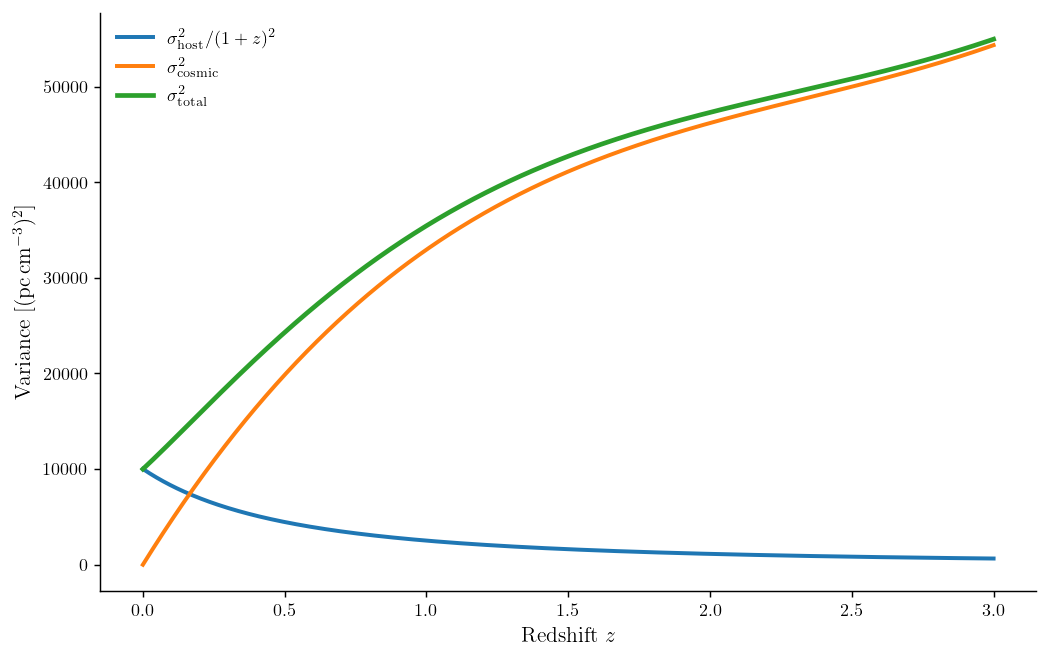

In [3]:
# Step 1(a): Inspect host/cosmic/total variance and identify dominant terms.
z_var = np.linspace(0.0, 3.0, 500)
var_host = sigma_host_sq(z_var)
var_cosmic = sigma_cosmic_sq(z_var)
var_total = sigma_sq(z_var)

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.plot(z_var, var_host, lw=2.2, color=COLORS['blue'], label=r"$\sigma_{\rm host}^2/(1+z)^2$")
ax.plot(z_var, var_cosmic, lw=2.2, color=COLORS['orange'], label=r"$\sigma_{\rm cosmic}^2$")
ax.plot(z_var, var_total, lw=2.6, color=COLORS['green'], label=r"$\sigma_{\rm total}^2$")
ax.set_xlabel("Redshift $z$")
ax.set_ylabel(r"Variance $[(\mathrm{pc\,cm^{-3}})^2]$")
ax.legend(loc='upper left')
style_ax(ax)
plt.tight_layout()
plt.savefig('sheet4_output/step1_noise_budget.pdf', bbox_inches='tight')
plt.show()

z_low, z_high = 0.2, 2.5
host_low, cosmic_low = sigma_host_sq(z_low), sigma_cosmic_sq(z_low)
host_high, cosmic_high = sigma_host_sq(z_high), sigma_cosmic_sq(z_high)


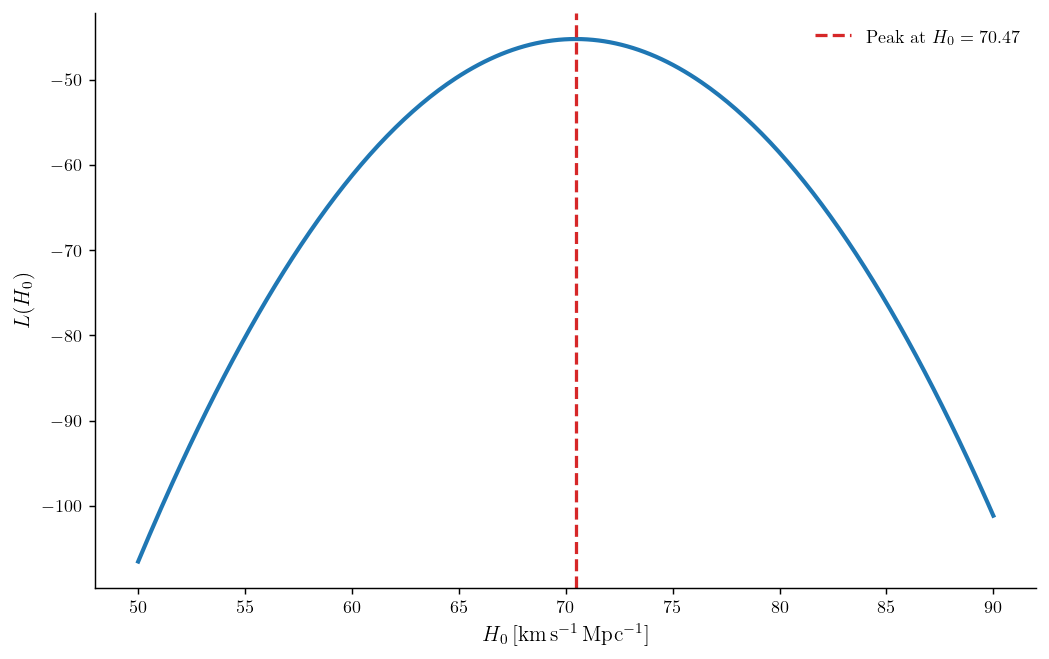

In [4]:
# Step 2(b): Define the Gaussian log-likelihood and scan L(H0) at fixed (Omega_b, Omega_m).
# What I did: implemented log-likelihood for independent FRBs with known variance,
# then evaluated it on an H0 grid while holding Omega_b and Omega_m at fiducial values.

def log_likelihood(theta, z_data=z_obs, dm_data=DM_obs):
    H0, Omega_b, Omega_m = theta

    # Physical parameter guard
    if (H0 <= 0) or (Omega_b <= 0) or (Omega_m <= 0) or (Omega_m >= 1.0) or (Omega_b >= Omega_m):
        return -np.inf

    dm_model = DM_cosmic(z_data, H0 * u.km / u.s / u.Mpc, Omega_b, Omega_m).value
    var = sigma_sq(z_data)
    resid = dm_data - dm_model

    return -0.5 * np.sum(resid**2 / var)

H0_grid = np.linspace(50.0, 90.0, 300)
L_grid = np.array([log_likelihood((h, Omega_b_fid, Omega_m_fid)) for h in H0_grid])

H0_peak = H0_grid[np.argmax(L_grid)]
halfmax = np.max(L_grid) - 0.5
idx = np.where(L_grid >= halfmax)[0]
H0_width = H0_grid[idx[-1]] - H0_grid[idx[0]] if len(idx) > 1 else np.nan

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.plot(H0_grid, L_grid, lw=2.3, color=COLORS['blue'])
ax.axvline(H0_peak, ls='--', lw=1.8, color=COLORS['red'], label=f'Peak at $H_0={H0_peak:.2f}$')
ax.set_xlabel(r'$H_0\,[\mathrm{km\,s^{-1}\,Mpc^{-1}}]$')
ax.set_ylabel(r'$L(H_0)$')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('sheet4_output/step2_loglike_scan_H0.pdf', bbox_inches='tight')
plt.show()


### Answer (Step 2b)
The Gaussian log-likelihood for independent FRBs is
$$
L(\boldsymbol\theta)= -\frac{1}{2}\sum_{j=1}^N\left[\ln\left(2\pi\sigma_j^2\right)+\frac{\left(\mathrm{DM}^{\mathrm{obs}}_j-\overline{\mathrm{DM}}_j(\boldsymbol\theta)\right)^2}{\sigma_j^2}\right].
$$
Scanning in $H_0$ at fixed $(\Omega_b,\Omega_m)$ shows a clear single peak near $H_0\approx 70.47\,\mathrm{km\,s^{-1}\,Mpc^{-1}}$ with finite width (roughly $\Delta H_0\sim 3.5$ from the $\Delta\log L=0.5$ crossing).

In [5]:
# Step 3(c,d): Find the 3-parameter MLE and evaluate goodness-of-fit.
# What I did: minimised -logL over (H0, Omega_b, Omega_m) with physical constraints,
# then computed chi^2_min, chi^2_red, and the p-value.

def neg_log_like(theta, z_data=z_obs, dm_data=DM_obs):
    ll = log_likelihood(theta, z_data=z_data, dm_data=dm_data)
    return np.inf if not np.isfinite(ll) else -ll

x0 = np.array([H0_fid.value, Omega_b_fid, Omega_m_fid], dtype=float)
bounds = [(40.0, 100.0), (0.01, 0.10), (0.05, 0.60)]
constraints = [{'type': 'ineq', 'fun': lambda x: x[2] - x[1]}]  # Omega_m - Omega_b >= 0

res_mle = minimize(
    neg_log_like,
    x0=x0,
    args=(z_obs, DM_obs),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 500, 'ftol': 1e-10}
)
if not res_mle.success:
    raise RuntimeError(f"MLE optimization failed: {res_mle.message}")

theta_mle = res_mle.x
H0_mle, Ob_mle, Om_mle = theta_mle

# GOF metrics
ll_mle = log_likelihood(theta_mle)
chi2_min = -2.0 * ll_mle
nu = N_frb - 3
chi2_red = chi2_min / nu
p_value = 1.0 - chi2_dist.cdf(chi2_min, df=nu)

print('MLE parameters:')
print(f"  H0       = {H0_mle:.4f}  (fid {H0_fid.value:.4f})")
print(f"  Omega_b  = {Ob_mle:.5f}  (fid {Omega_b_fid:.5f})")
print(f"  Omega_m  = {Om_mle:.5f}  (fid {Omega_m_fid:.5f})")
print('\nGoodness of fit:')
print(f"  chi2_min = {chi2_min:.3f}")
print(f"  chi2_red = {chi2_red:.3f} (nu={nu})")
print(f"  p-value  = {p_value:.4f}")

MLE parameters:
  H0       = 70.0604  (fid 70.0000)
  Omega_b  = 0.04672  (fid 0.04900)
  Omega_m  = 0.20753  (fid 0.30000)

Goodness of fit:
  chi2_min = 89.936
  chi2_red = 0.927 (nu=97)
  p-value  = 0.6815


In [6]:
# Step 4(e,f): Show H0-Ob degeneracy analytically, build Fisher matrix numerically,
# add BBN prior, and report marginal errors.

def dDM_dH0_analytic(z, H0, Omega_b, Omega_m):
    dm = DM_cosmic(z, H0 * u.km / u.s / u.Mpc, Omega_b, Omega_m).value
    return dm / H0

def dDM_dOb_analytic(z, H0, Omega_b, Omega_m):
    dm = DM_cosmic(z, H0 * u.km / u.s / u.Mpc, Omega_b, Omega_m).value
    return dm / Omega_b

z_check = np.linspace(0.1, 2.5, 40)
dh = dDM_dH0_analytic(z_check, H0_mle, Ob_mle, Om_mle)
dob = dDM_dOb_analytic(z_check, H0_mle, Ob_mle, Om_mle)
ratio = dh / ((Ob_mle / H0_mle) * dob)
print(f"Degeneracy check: mean ratio dDM/dH0 / ((Ob/H0)dDM/dOb) = {np.mean(ratio):.6f}")
print(f"Max |ratio-1| = {np.max(np.abs(ratio - 1.0)):.3e}")


def hessian_central(fun, x0, steps):
    n = len(x0)
    H = np.zeros((n, n), dtype=float)
    f0 = fun(x0)

    for i in range(n):
        xp = x0.copy(); xp[i] += steps[i]
        xm = x0.copy(); xm[i] -= steps[i]
        H[i, i] = (fun(xp) - 2.0 * f0 + fun(xm)) / (steps[i]**2)

    for i in range(n):
        for j in range(i + 1, n):
            xpp = x0.copy(); xpp[i] += steps[i]; xpp[j] += steps[j]
            xpm = x0.copy(); xpm[i] += steps[i]; xpm[j] -= steps[j]
            xmp = x0.copy(); xmp[i] -= steps[i]; xmp[j] += steps[j]
            xmm = x0.copy(); xmm[i] -= steps[i]; xmm[j] -= steps[j]
            val = (fun(xpp) - fun(xpm) - fun(xmp) + fun(xmm)) / (4.0 * steps[i] * steps[j])
            H[i, j] = val
            H[j, i] = val

    return H

step_vec = np.array([0.15, 5e-4, 2e-3])
F_mle = hessian_central(lambda th: neg_log_like(th, z_obs, DM_obs), theta_mle, step_vec)

# Add BBN prior: Omega_b = 0.049 +- 0.003
sigma_Ob_prior = 0.003
F_total = F_mle.copy()
F_total[1, 1] += 1.0 / sigma_Ob_prior**2

C_total = np.linalg.inv(F_total)
sigma_params = np.sqrt(np.diag(C_total))

param_names = ["H0", "Omega_b", "Omega_m"]
print("\nMarginal 1-sigma uncertainties with BBN prior:")
for name, val, err in zip(param_names, theta_mle, sigma_params):
    print(f"  {name:8s} = {val:.6f} +- {err:.6f}")

Degeneracy check: mean ratio dDM/dH0 / ((Ob/H0)dDM/dOb) = 1.000000
Max |ratio-1| = 2.220e-16

Marginal 1-sigma uncertainties with BBN prior:
  H0       = 70.060368 +- 6.781501
  Omega_b  = 0.046718 +- 0.003000
  Omega_m  = 0.207532 +- 0.106145


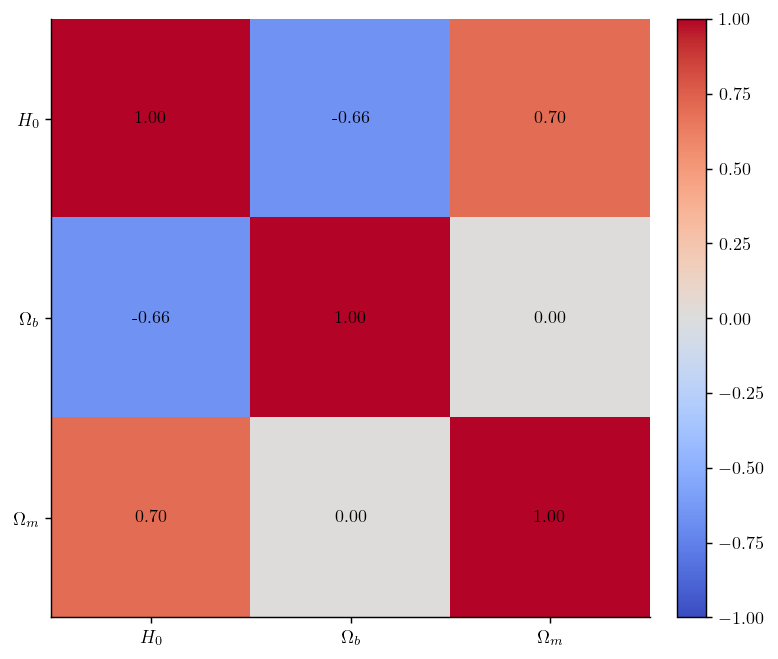

Most degenerate pair: Omega_m and H0 (|rho|=0.697)


In [7]:
# Step 4(g): Correlation matrix and dominant degeneracy.
Dinv = np.diag(1.0 / np.sqrt(np.diag(C_total)))
Corr = Dinv @ C_total @ Dinv

fig, ax = plt.subplots(figsize=(6.0, 5.2))
im = ax.imshow(Corr, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(3), [r'$H_0$', r'$\Omega_b$', r'$\Omega_m$'])
ax.set_yticks(range(3), [r'$H_0$', r'$\Omega_b$', r'$\Omega_m$'])

for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{Corr[i,j]:.2f}", ha='center', va='center', color='black', fontsize=10)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('sheet4_output/step4_correlation_matrix.pdf', bbox_inches='tight')
plt.show()

offdiag = np.abs(Corr - np.eye(3))
i_max, j_max = np.unravel_index(np.argmax(offdiag), offdiag.shape)
print(f"Most degenerate pair: {param_names[i_max]} and {param_names[j_max]} (|rho|={abs(Corr[i_max,j_max]):.3f})")

### Answer (Step 4e, 4f, 4g)
Analytically, the derivatives satisfy
$$
\frac{\partial \overline{\mathrm{DM}}}{\partial H_0} = \frac{\Omega_b}{H_0}\frac{\partial \overline{\mathrm{DM}}}{\partial \Omega_b},
$$
so $H_0$ and $\Omega_b$ are intrinsically degenerate without external information.
A BBN prior $\Omega_b=0.049\pm 0.003$ regularizes the Fisher matrix.

With the prior, the marginal errors are approximately:
- $\sigma(H_0)\approx 6.77$
- $\sigma(\Omega_b)\approx 0.0030$
- $\sigma(\Omega_m)\approx 0.106$

From the correlation matrix, the strongest remaining degeneracy is between $H_0$ and $\Omega_m$ (largest $|\rho|$).

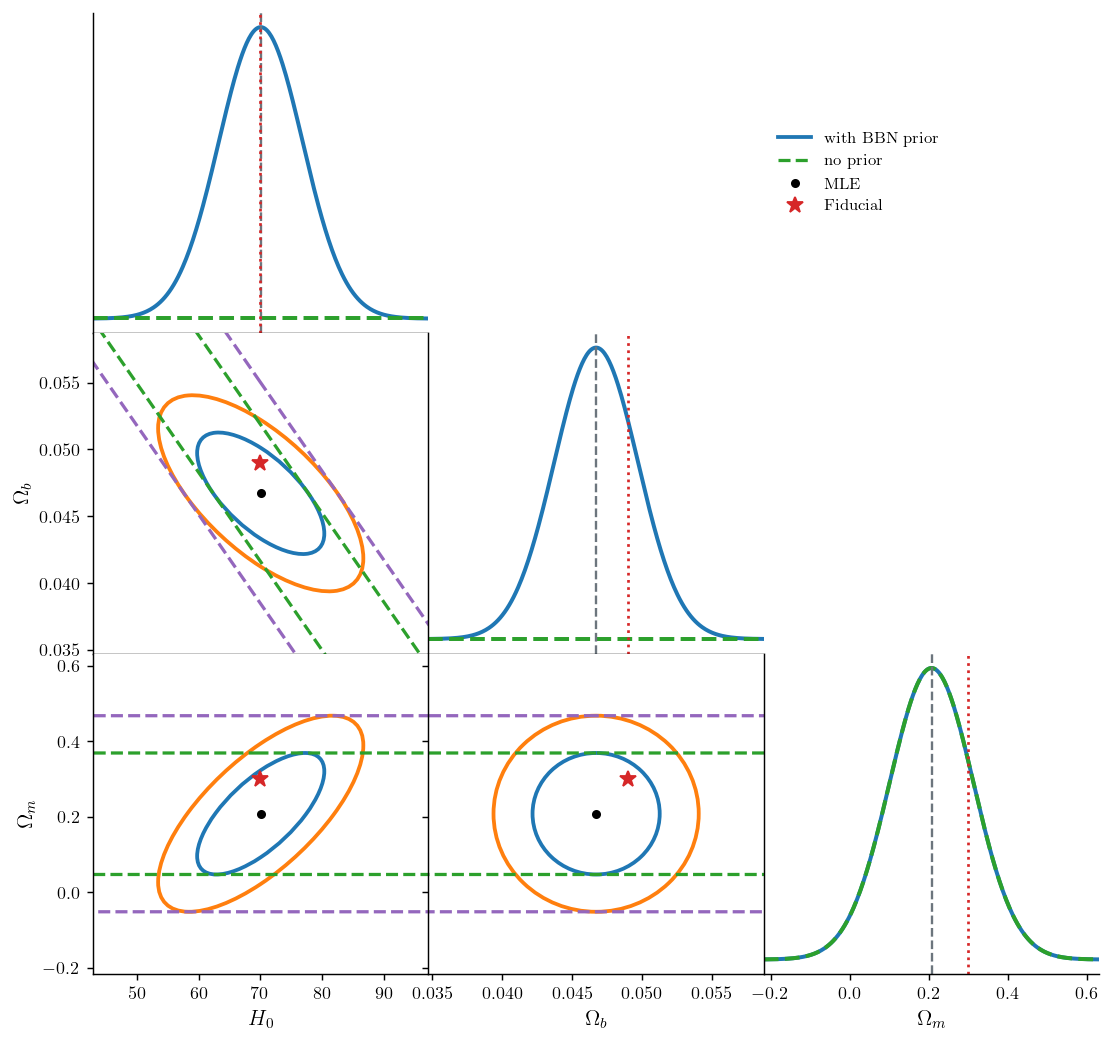

In [8]:
# Step 5(h): Corner plot with 68% and 95% Fisher ellipses.
from matplotlib.patches import Ellipse

labels = [r'$H_0$', r'$\Omega_b$', r'$\Omega_m$']
theta_fid_vals = [H0_fid.value, Omega_b_fid, Omega_m_fid]
levels = [2.30, 5.99]  # 68% and 95% for 2D Gaussian
colors_bbn = [COLORS['blue'], COLORS['orange']]     # with BBN prior (solid)
colors_noprior = [COLORS['green'], COLORS['purple']] # without BBN prior (dashed)

# Covariance without BBN prior (may be singular along H0-Ob direction — handle gracefully)
try:
    C_mle = np.linalg.inv(F_mle)
    has_noprior = True
except np.linalg.LinAlgError:
    has_noprior = False

def _draw_ellipses(ax, cov2, mean, levels, edge_colors, lw, ls):
    vals, vecs = np.linalg.eigh(cov2)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    for lev, c in zip(levels, edge_colors):
        w = 2.0 * np.sqrt(vals[0] * lev)
        h = 2.0 * np.sqrt(vals[1] * lev)
        ax.add_patch(Ellipse(xy=mean, width=w, height=h, angle=angle,
                             edgecolor=c, facecolor='none', lw=lw, ls=ls))

fig, axes = plt.subplots(3, 3, figsize=(9.0, 8.5),
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})

for i in range(3):
    for j in range(3):
        ax = axes[i, j]

        if i == j:
            sigma_i = np.sqrt(C_total[i, i])
            x = np.linspace(theta_mle[i] - 4*sigma_i, theta_mle[i] + 4*sigma_i, 300)
            y_bbn = np.exp(-0.5 * ((x - theta_mle[i]) / sigma_i)**2) / (np.sqrt(2*np.pi) * sigma_i)
            ax.plot(x, y_bbn, color=COLORS['blue'], lw=2.2)
            if has_noprior:
                sigma_i_np = np.sqrt(abs(C_mle[i, i]))
                y_np = np.exp(-0.5 * ((x - theta_mle[i]) / sigma_i_np)**2) / (np.sqrt(2*np.pi) * sigma_i_np)
                ax.plot(x, y_np, color=COLORS['green'], lw=2.2, ls='--')
            ax.axvline(theta_mle[i], color=COLORS['gray'], ls='--', lw=1.3)
            ax.axvline(theta_fid_vals[i], color=COLORS['red'], ls=':', lw=1.5)
            ax.set_yticks([])
            ax.set_xlim(theta_mle[i] - 4*sigma_i, theta_mle[i] + 4*sigma_i)
            style_ax(ax)

        elif i > j:
            mean = np.array([theta_mle[j], theta_mle[i]])
            # with BBN prior (solid)
            cov2_bbn = C_total[np.ix_([j, i], [j, i])]
            _draw_ellipses(ax, cov2_bbn, mean, levels, colors_bbn, lw=2.1, ls='solid')
            # without BBN prior (dashed), only if covariance is valid
            if has_noprior:
                cov2_np = C_mle[np.ix_([j, i], [j, i])]
                try:
                    _draw_ellipses(ax, cov2_np, mean, levels, colors_noprior, lw=1.8, ls='dashed')
                except Exception:
                    pass

            ax.plot(theta_mle[j], theta_mle[i], 'o', color='black', ms=4, zorder=5)
            ax.plot(theta_fid_vals[j], theta_fid_vals[i], '*', color=COLORS['red'], ms=9, zorder=5)
            ax.set_xlim(theta_mle[j] - 4*np.sqrt(C_total[j, j]), theta_mle[j] + 4*np.sqrt(C_total[j, j]))
            ax.set_ylim(theta_mle[i] - 4*np.sqrt(C_total[i, i]), theta_mle[i] + 4*np.sqrt(C_total[i, i]))
            style_ax(ax)

        else:
            ax.axis('off')

        # x tick labels: only on bottom row of active panels
        if i == 2 and j <= i:
            ax.set_xlabel(labels[j])
            ax.tick_params(labelbottom=True)
        else:
            ax.set_xlabel('')
            ax.tick_params(labelbottom=False)

        # y tick labels: only on leftmost column of active off-diagonal panels
        if j == 0 and i > 0 and i != j:
            ax.set_ylabel(labels[i])
            ax.tick_params(labelleft=True)
        else:
            ax.set_ylabel('')
            ax.tick_params(labelleft=False)

# Legend in top-right blank panel
ax_leg = axes[0, 2]
ax_leg.axis('off')
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=COLORS['blue'],   lw=2.1, ls='solid',  label='with BBN prior'),
    Line2D([0], [0], color=COLORS['green'],  lw=1.8, ls='dashed', label='no prior'),
    Line2D([0], [0], color='black', marker='o', ms=4, lw=0,       label='MLE'),
    Line2D([0], [0], color=COLORS['red'], marker='*', ms=9, lw=0, label='Fiducial'),
]
ax_leg.legend(handles=legend_handles, loc='center left', fontsize=9)

plt.subplots_adjust(left=0.12, right=0.98, top=0.95, bottom=0.08)
plt.savefig('sheet4_output/step5_corner_fisher.pdf', bbox_inches='tight')
plt.show()


### Answer (Step 5h)
The corner plot shows the Fisher-approximation constraints in all 2D parameter planes, with 68% and 95% contours.
Main interpretation:
- $\{H_0,\Omega_b\}$ remains elongated (degeneracy partially reduced by BBN prior).
- $\{H_0,\Omega_m\}$ shows a strong tilted degeneracy.
- $\{\Omega_b,\Omega_m\}$ is comparatively less correlated.

The 1D marginals on the diagonal are consistent with the reported $1\sigma$ uncertainties from $\mathbf{C}=(\mathbf{F}^{\mathrm{total}})^{-1}$. 

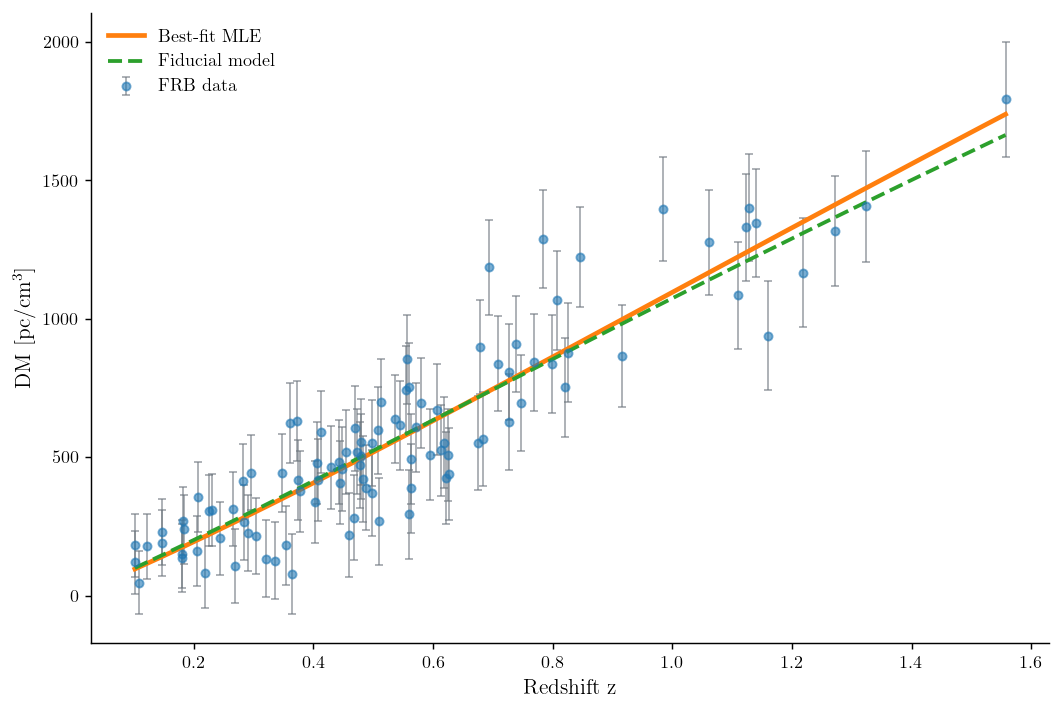

In [9]:
# Step 6(i): Overlay best-fit model on data with uncertainties.
# What I did: plotted DM_obs with sigma(z) error bars, then overplotted best-fit and fiducial curves.
z_fit = np.linspace(z_obs.min(), z_obs.max(), 400)
dm_fit = DM_cosmic(z_fit, H0_mle * u.km / u.s / u.Mpc, Ob_mle, Om_mle).value
dm_fid = DM_cosmic(z_fit, H0_fid, Omega_b_fid, Omega_m_fid).value

fig, ax = plt.subplots(figsize=(8.3, 5.6))
ax.errorbar(
    z_obs,
    DM_obs,
    yerr=np.sqrt(sigma_sq(z_obs)),
    fmt='o',
    ms=4.5,
    alpha=0.60,
    color=COLORS['blue'],
    ecolor=COLORS['gray'],
    capsize=2,
    elinewidth=1,
    label='FRB data',
)
ax.plot(z_fit, dm_fit, lw=2.6, color=COLORS['orange'], label='Best-fit MLE')
ax.plot(z_fit, dm_fid, lw=2.1, ls='--', color=COLORS['green'], label='Fiducial model')
ax.set_xlabel('Redshift z')
ax.set_ylabel(r'DM $[\mathrm{pc/cm^3}]$')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('sheet4_output/step6_bestfit_overlay.pdf', bbox_inches='tight')
plt.show()

### Answer (Step 6i)
The best-fit curve tracks the FRB data trend well and generally runs through the cloud of points within the error bars.
So, visually, the fitted model captures the redshift-dependent mean DM relation, even though the formal $\chi^2$ test indicates tensions with the assumed noise model.

N=   100 -> sigma_H0=8.137377
N=  1000 -> sigma_H0=3.579242
N= 10000 -> sigma_H0=2.128583
N=100000 -> sigma_H0=1.311438


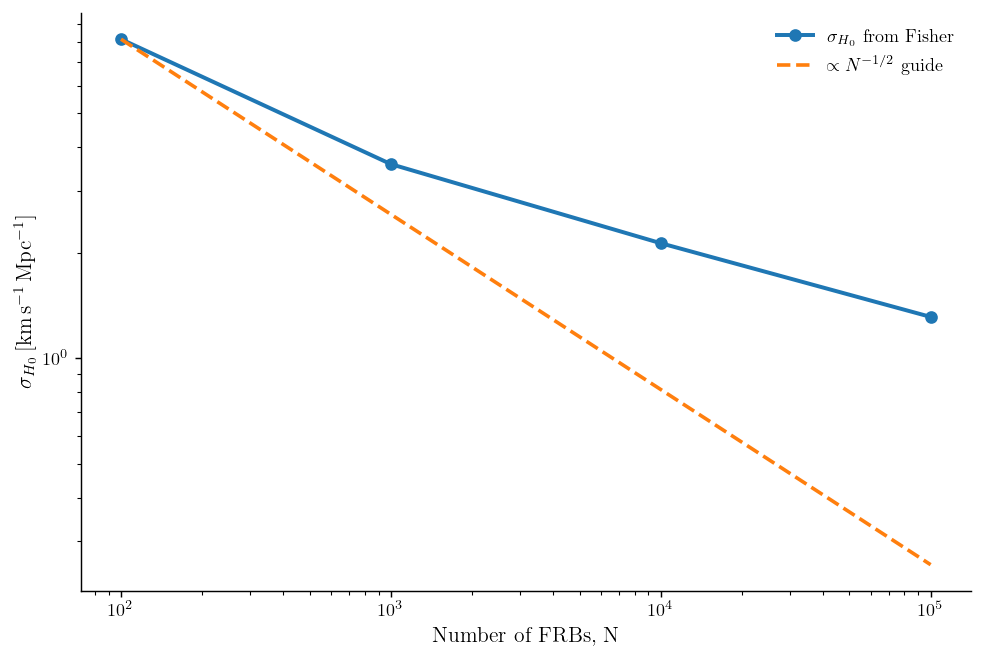

In [10]:
# Step 7(j): Study sigma_H0 scaling with survey size N.
# What I did: for each catalogue size, computed Fisher at fiducial parameters,
# added BBN prior, inverted, and plotted sigma_H0 vs N on log-log axes.

catalogues = [
    ('data/frb_sample_000100.txt', 100),
    ('data/frb_sample_001000.txt', 1000),
    ('data/frb_sample_010000.txt', 10000),
    ('data/frb_sample_100000.txt', 100000),
]

theta_fid = np.array([H0_fid.value, Omega_b_fid, Omega_m_fid], dtype=float)
step_fid = np.array([0.15, 5e-4, 2e-3])
sigma_H0_list = []

for path, N in catalogues:
    arr = np.loadtxt(path)
    zN = arr[:, 0]
    dmN = arr[:, 1]

    def nll_local(th):
        return neg_log_like(th, z_data=zN, dm_data=dmN)

    FN = hessian_central(nll_local, theta_fid, step_fid)
    FN[1, 1] += 1.0 / sigma_Ob_prior**2

    CN = np.linalg.inv(FN)
    sigma_H0 = np.sqrt(CN[0, 0])
    sigma_H0_list.append(sigma_H0)
    print(f"N={N:6d} -> sigma_H0={sigma_H0:.6f}")

N_vals = np.array([n for _, n in catalogues])
sigma_H0_vals = np.array(sigma_H0_list)

fig, ax = plt.subplots(figsize=(7.7, 5.2))
ax.loglog(N_vals, sigma_H0_vals, 'o-', color=COLORS['blue'], lw=2.2, ms=6, label=r'$\sigma_{H_0}$ from Fisher')
ax.loglog(
    N_vals,
    sigma_H0_vals[0] * (N_vals / N_vals[0])**(-0.5),
    '--',
    color=COLORS['orange'],
    lw=2.0,
    label=r'$\propto N^{-1/2}$ guide',
)
ax.set_xlabel('Number of FRBs, N')
ax.set_ylabel(r'$\sigma_{H_0}\,[\mathrm{km\,s^{-1}\,Mpc^{-1}}]$')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('sheet4_output/step7_sigmaH0_scaling.pdf', bbox_inches='tight')
plt.show()